# Diseño e Implementación de un Sistema de Comunicación LoRa

***

##### **Asignatura:** Comunicaciones Digitales
##### **Docentes:** Corral Briones, Graciela — Ayarde, J. Martín
##### **Alumnos:** Graham, Enrique Lenox — Mamani, Franco Iván
##### **Grupo:** LenoxLegends
##### **Año de Cursado:** 2024

***

## Introducción

En este Trabajo Práctico Integrador construimos un sistema de comunicación LoRa **bloque por bloque**, partiendo del codec (bits ↔ símbolos), pasando por el modulador y los canales (AWGN + multipath), y terminando con la implementación del sistema completo sobre hardware real.

La modulación se basa en **chirps** — señales cuya frecuencia barre todo el ancho de banda durante un símbolo. A lo largo del trabajo vamos a ver por qué esa estructura resulta robusta frente al ruido y a la distorsión introducida por el canal.

Cada bloque se valida en aislamiento: el codec con un round-trip de BER = 0, el waveformer + n-tuple former con SER = 0 sin canal, el sistema completo en simulación comparando las curvas BER vs SNR contra la Figura 1 del paper de Vangelista (2017), y finalmente el sistema sobre SDR confirmando que se recuperan los símbolos transmitidos. La justificación teórica del receptor óptimo viene del Rimoldi (2016, Cap 2–3).


## Bloques del sistema

El sistema sigue el esquema clásico de un sistema de comunicación digital (Rimoldi 2016, Cap 1):

![Diagrama de un sistema de comunicación digital](rimoldi_sistema.png)

**Transmisor:**
- **Encoder (Codec):** convierte bits en símbolos enteros.
- **Waveform Former:** convierte cada símbolo en un chirp complejo (modulación FSCM — *Frequency Shift Chirp Modulation*).

**Canal:**
- Suma **ruido AWGN** (térmico, gaussiano blanco aditivo).
- Introduce **distorsión multipath** modelada como un filtro selectivo en frecuencia.

**Receptor:**
- **n-Tuple Former:** demodula el chirp recibido mediante *dechirp + FFT + argmax*, recuperando el símbolo más probable (criterio ML).
- **Decoder:** convierte el símbolo de vuelta a bits.

## Alcance del Trabajo

El trabajo se divide en dos partes complementarias:

- **Parte 1 — Implementación Software (Vangelista 2017, Módulos 1-4):** sistema TX/RX completo en simulación, validado contra las curvas BER/SER del paper.
- **Parte 2 — SDR (Módulo 5.1):** implementación del sistema sobre hardware real (PlutoSDR) en modo loopback.

Este notebook integra los cinco módulos del sistema:
:

| Módulo | Contenido | Bloque del sistema |
|---|---|---|
| **1 — Codec** | Codificador y decodificador bits ↔ símbolos según Ec. (1) de Vangelista | Encoder / Decoder |
| **2 — Waveform Former** | Generación de chirps según Ec. (3) y demodulación óptima (Sección III) | Waveform Former / n-Tuple Former |
| **3 — Canal AWGN** | Ruido térmico y curvas BER/SER vs SNR comparadas con la Figura 1 del paper | Canal (ruido) |
| **4 — Canal Selectivo** | Multipath con respuesta $h(nT) = \sqrt{0.8}\,\delta(nT) + \sqrt{0.2}\,\delta(nT-T)$ | Canal (distorsión) |
| **5 — SDR Loopback** | TX/RX completo sobre un único PlutoSDR (loopback digital y por antena) | Sistema completo en hardware |


**Criterio de validación (Parte 1):** las curvas BER/SER simuladas vía Monte Carlo deben aproximarse a las curvas FSCM-Flat y FSCM-Frequency-Selective publicadas en Vangelista (2017), Figura 1.

**Criterio de validación (Parte 2):** el sistema debe recuperar correctamente los símbolos transmitidos en loopback sobre PlutoSDR.


## Referencias

[1] **Vangelista, L.** (2017). *Frequency Shift Chirp Modulation: The LoRa Modulation*.

[2] **Rimoldi, B.** (2016). *Principles of Digital Communication: A Top-Down Approach*.

---

## Configuración inicial — Imports y parámetros globales

### Parámetros fundamentales del sistema LoRa

| Parámetro | Símbolo | Valor | Descripción |
|---|---|---|---|
| **Spreading Factor** | $SF$ | 7 | Cantidad de bits por símbolo. Define el rango de símbolos posibles: $s \in \{0, 1, \dots, 2^{SF}-1\}$. |
| **Tamaño del alfabeto** | $M = 2^{SF}$ | 128 | Cantidad de chirps distintos = cantidad de muestras (chips) por símbolo. |
| **Ancho de banda** | $BW$ | 125 kHz | Ancho de banda del canal. |
| **Frecuencia de muestreo** | $f_s$ | $BW$ = 125 kHz | Una muestra por chip. |
| **Período de chip** | $T = 1/BW$ | 8 μs | Duración de cada chip (muestra) dentro del símbolo. |
| **Período de símbolo** | $T_s = M \cdot T$ | 1.024 ms | Duración total de un símbolo (128 chips × 8 μs). |

> Cada parámetro se profundiza en el módulo donde aparece, esta tabla es solo una referencia rápida.


### Imports y declaración de parámetros

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.gridspec as gridspec

# === Parámetros globales del sistema LoRa ===
SF = 7              # Spreading Factor (bits por símbolo)
M  = 2 ** SF        # Tamaño del alfabeto = chips por símbolo (= 128)
BW = 125e3          # Ancho de banda [Hz]
fs = BW             # Frecuencia de muestreo (complex baseband, sin oversampling: fs = BW)
T  = 1 / BW         # Período de chip [s]
Ts = M / BW         # Duración del símbolo [s]

print("Parámetros globales:")
print(f"  SF = {SF}")
print(f"  M  = {M} (símbolos / chips por símbolo)")
print(f"  BW = {BW/1e3:.0f} kHz")
print(f"  fs = {fs/1e3:.0f} kHz")
print(f"  T  = {T*1e6:.2f} us")
print(f"  Ts = {Ts*1e3:.3f} ms")


Parámetros globales:
  SF = 7
  M  = 128 (símbolos / chips por símbolo)
  BW = 125 kHz
  fs = 125 kHz
  T  = 8.00 us
  Ts = 1.024 ms


# Módulo 1 — Codec (Codificador / Decodificador)

En esta primera parte implementamos el primer bloque de la capa física del sistema LoRa: el **codec**, que convierte un flujo de bits en una secuencia de símbolos enteros, y reconstruye los bits a partir de esos símbolos.

---

## 1. Ubicación en el sistema

Dentro del diagrama (Rimoldi 2016, Cap 1), este módulo cubre los bloques **Encoder** (transmisor) y **Decoder** (receptor) — el dominio puramente digital, antes de la modulación con chirps. Trabajamos exclusivamente con la transformación bits ↔ símbolos enteros, sin canal todavía.

## 2. Conceptos básicos

Un **símbolo** es la unidad de información que se transmite por el canal en cada **período de símbolo** $T_s$ (la duración de un símbolo). Se elige de un alfabeto finito $\mathcal{H} = \{0, 1, \ldots, M-1\}$.

El **Spreading Factor (SF)** define dos cosas en LoRa:

- Cuántos bits cargo en cada símbolo: $SF$ bits.
- Tamaño del alfabeto: $M = 2^{SF}$.

### Ejemplo:

Si los bits fueran `0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1` (16 bits). Con SF=4 los agrupo de a 4 y convierto cada grupo a entero usando la **convención LSB-first del paper de Vangelista** (el primer bit del grupo pesa $2^0=1$, el último $2^{SF-1}$):

| Grupo (4 bits) | Cálculo (LSB-first) | Decimal |
|----------------|---------------------|---------|
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1000` | $1·1 + 0·2 + 0·4 + 0·8$ | 1 |
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1111` | $1·1 + 1·2 + 1·4 + 1·8$ | 15 |

**Resultado:** 16 bits → 4 símbolos `[2, 1, 2, 15]`.

## 3. Diseño del codec

### Codificación: de bits a símbolos

El codificador se basa en la **ecuación (1) del paper de Vangelista (2017)**, que define formalmente cómo se mapea un bloque de SF bits a un símbolo entero:

$$s(nT_s) = \sum_{h=0}^{SF-1} w(nT_s)_h \cdot 2^h \quad \quad \quad \quad \quad \text{(1)}$$

**Variables:**

- $s(nT_s)$: símbolo resultante (entero en el rango $[0, 2^{SF}-1]$).
- $w(nT_s)_h$: bit en la posición $h$ del bloque ($w_h \in \{0, 1\}$).
- $SF$: Spreading Factor (cantidad de bits por símbolo).
- $nT_s$: instante temporal del símbolo número $n$. Es notación de tiempo discreto: $T_s$ es la duración de un símbolo, y $n$ es el índice.

**Convención LSB-first**: el bit en posición $h$ pesa $2^h$. El primer bit del bloque vale $2^0=1$, el último vale $2^{SF-1}$.

### Aplicación al ejemplo SF=4

Para el bloque $w = [0, 1, 0, 0]$ con SF=4:

| $h$ | $w_h$ | $2^h$ | $w_h \cdot 2^h$ |
|-----|-------|-------|-------------------|
| 0 | 0 | 1 | 0 |
| 1 | 1 | 2 | 2 |
| 2 | 0 | 4 | 0 |
| 3 | 0 | 8 | 0 |

Suma: $s = 0 + 2 + 0 + 0 = 2$

### Decodificación: de símbolo a bits

La fórmula del decoder no aparece en el paper de Vangelista — el paper solo define el encoder (Ec. 1). Por lo que se deriva como la inversa matemática de Eq. (1):

$$w_h = \lfloor s \,/\, 2^h \rfloor \bmod 2 \;=\; (s \gg h) \,\&\, 1$$

para $h = 0, 1, \ldots, SF-1$.

**Variables:**
- $w_h$: bit recuperado en la posición $h$.
- $s$: símbolo entero del que queremos extraer los bits.
- $\bmod 2$: operador de módulo 2 (resto de la división entera por 2).


### Aplicación al ejemplo SF=4

Para verificar que el decoder es la inversa exacta del encoder, decodificamos el símbolo $s = 2$ que obtuvimos arriba (con SF=4) y comprobamos que recuperamos el bloque original $w = [0, 1, 0, 0]$:

| $h$ | $\lfloor s / 2^h \rfloor$ | $w_h = \lfloor s / 2^h \rfloor \bmod 2$ |
|-----|---------------------------|-----------------------------------------|
| 0 | $\lfloor 2/1 \rfloor = 2$ | $2 \bmod 2 = 0$ |
| 1 | $\lfloor 2/2 \rfloor = 1$ | $1 \bmod 2 = 1$ |
| 2 | $\lfloor 2/4 \rfloor = 0$ | $0 \bmod 2 = 0$ |
| 3 | $\lfloor 2/8 \rfloor = 0$ | $0 \bmod 2 = 0$ |


Bloque recuperado: $w = [0, 1, 0, 0]$  — coincide con el bloque original que entró al encoder. El round-trip cierra perfectamente.

## 4. Bit Error Rate (BER)

El **Bit Error Rate (BER)** se define como:

$$\text{BER} = \frac{\text{cantidad de bits erróneos}}{\text{cantidad de bits transmitidos}}$$

Sin canal, esperamos **BER = 0** en cualquier round-trip (encoder → decoder). Cuando agreguemos ruido AWGN en el Módulo 3, la BER va a aumentar y vamos a compararla contra las curvas publicadas en el paper de Vangelista (2017), Figura 1.


## 5. Implementación

### `bits_to_symbols(bits, SF)` — codificador

In [110]:
def bits_to_symbols(bits, SF):
    #1-Verificamos que len(bits) sea múltiplo de SF
    if len(bits) % SF != 0:
        raise ValueError(f"len(bits)={len(bits)} no es múltiplo de SF={SF}")
    
    #2- Reshape a matriz (n_simbolos, SF)
    n_simbolos = len(bits) // SF
    matriz = bits.reshape(n_simbolos, SF)
    
    #3- Crear vector de pesos para convertir bits a símbolos
    pesos = 2 ** np.arange(SF) 
    
    # Paso 4: Producto matricial → símbolos
    simbolos = matriz @ pesos
    
    return simbolos

### `symbols_to_bits(symbols, SF)` — decodificador

In [111]:
def symbols_to_bits(symbols, SF):
    #1-Reshape a matriz (n_simbolos, 1)
    symbols_col = symbols.reshape(-1, 1)

    #2- Creamos vector de shifts LBS-MSB
    shifts = np.arange(SF)

    #3- Desplazamos bits a la derecha y aplicamos AND para extraer cada bit
    matriz = (symbols_col >> shifts) & 1

    # Paso 4: Aplanar a vector 1D
    bits = matriz.flatten() 
    
    return bits

### `calcular_ber(bits_tx, bits_rx)` — métrica de errores

In [112]:
def calcular_ber(bits_tx, bits_rx):
    errores = np.sum(bits_tx != bits_rx)
    ber = errores / len(bits_tx)
    return ber

## 6. Tests

In [113]:

def test_round_trip(num_bits, SF):

    print(f"TEST: {num_bits} bits aleatorios (SF={SF})")

    # Generar bits aleatorios
    
    bits_tx = np.random.randint(0, 2, num_bits)
    #bits_tx = np.array([0,1,0,0,0,0,0])
    print(f"  Bits TX: {bits_tx}")

    # Codificar
    symbols = bits_to_symbols(bits_tx, SF)
    print(f"  Símbolos: {symbols}")

    # Decodificar
    bits_rx = symbols_to_bits(symbols, SF)
    print(f"  Bits RX: {bits_rx}")

    # Calcular BER
    ber = calcular_ber(bits_tx, bits_rx)
    print(f"  BER = {ber}")
    return ber


# Tests de round-trip 
test_round_trip(num_bits=70,   SF=7);


TEST: 70 bits aleatorios (SF=7)
  Bits TX: [0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 0]
  Símbolos: [ 6 26 73 70 92 17 10 86 83 47]
  Bits RX: [0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 0]
  BER = 0.0


# Módulo 2 — Waveform Former y n-Tuple Former (Modulación LoRa)

La modulación que implementamos se llama **Frequency Shift Chirp Modulation (FSCM)** (Vangelista 2017). Este módulo implementa dos bloques de la capa física LoRa:

- **Waveform Former (TX):** convierte cada símbolo entero en un chirp complejo según la Ec. (3) de Vangelista (2017).
- **n-Tuple Former (RX):** recupera el símbolo a partir del chirp recibido vía *dechirp + DFT + argmax*.

Sin canal todavía, validamos que el sistema no tenga errores (SER = 0).

---

## 1. Ubicación en el sistema

Dentro del diagrama (Rimoldi 2016, Cap 1), este módulo cubre los bloques **Waveform Former** (transmisor) y **n-Tuple Former** (receptor) — la modulación/demodulación que convierte símbolos en formas de onda y viceversa. El canal todavía es ideal (sin ruido ni distorsión).

## 2. Conceptos básicos

### Chirp y chip

Un **chirp** es una señal cuya **frecuencia instantánea cambia con el tiempo**. En LoRa, cada chirp tiene fase cuadrática en $k$, lo cual produce una frecuencia que crece linealmente — un *up-chirp*.

Un **chip** es una **muestra discreta** del chirp. Cada símbolo se discretiza en $M = 2^{SF}$ chips. 

### Ortogonalidad de los chirps

Como vimos antes, LoRa usa un alfabeto de $M$ símbolos. A cada símbolo le corresponde una señal, y esas $M$ señales son **mutuamente ortogonales**:

$$\langle c_s, c_{s'} \rangle = \sum_{k=0}^{M-1} c_s[k] \cdot c_{s'}^*[k] = \delta_{s, s'}$$

donde $\delta_{s,s'}$ es la **delta de Kronecker** (vale 1 si $s=s'$, 0 si $s \neq s'$).

Como además cada chirp tiene energía 1 ($\langle c_s, c_s\rangle = 1$, gracias al factor $1/\sqrt{M}$ que veremos en la parte 3), los $M$ chirps forman una **base ortonormal**. Esa propiedad es la clave del demodulador (parte 4) y conecta directamente con el receptor óptimo de Rimoldi.

## 3. Diseño del waveformer — Ecuación (3) de Vangelista

### La fórmula

El waveformer se basa en la **ecuación (3) del paper de Vangelista (2017)**, que define el chirp para el símbolo $s$:

$$c_s[k] \;=\; \frac{1}{\sqrt{M}}\,\exp\!\left(j\,2\pi \cdot \big[(s + k) \bmod M\big] \cdot \frac{k}{M}\right) \qquad \text{(3)}$$

Esta es la forma simplificada de la fórmula del paper, que sale de la Ec.(2) usando $T = 1/B$ (período de chip = inverso del ancho de banda), con lo cual $kT \cdot B = k$.

**Variables:**

- $s$: símbolo a transmitir, entero en $[0, M-1]$.
- $k$: índice de chip dentro del símbolo, $k \in \{0, 1, \dots, M-1\}$.
- $M = 2^{SF}$: tamaño del alfabeto = chips por símbolo.
- $T = T_s/M = 1/BW$: período de chip (segundos).
- $1/\sqrt{M}$: normalización para que $E_s = \sum_k |c_s|^2 = 1$.

### Las 3 partes de la fórmula

1. **Normalización** $1/\sqrt{M}$: hace que la energía $E_s = 1$.
2. **Suma modular** $(s+k) \bmod M$: codifica el símbolo $s$ como *shift cíclico* del chirp básico ($s=0$).
3. **Rampa** $k/M$: el factor que multiplica a $(s+k) \bmod M$ produce una fase cuadrática en $k$, lo cual hace que la frecuencia instantánea crezca linealmente. Eso es lo que vuelve a la señal un "chirp".

### Mini-ejemplo: SF=2 (M=4)

Para $SF=2$ tenemos 4 chirps posibles:

| Símbolo $s$ | Chirp $c_s$ (normalizado por $1/2$) |
|---|---|
| 0 | $\tfrac{1}{2}[+1,\, +j,\, +1,\, +j]$ |
| 1 | $\tfrac{1}{2}[+1,\, -1,\, -1,\, +1]$ |
| 2 | $\tfrac{1}{2}[+1,\, -j,\, +1,\, -j]$ |
| 3 | $\tfrac{1}{2}[+1,\, +1,\, -1,\, -1]$ |

Verificación de ortogonalidad: $\langle c_0, c_1 \rangle = \tfrac{1}{4}(1 - j - 1 + j) = 0$ ✓

Verificación de energía: $\langle c_0, c_0 \rangle = \tfrac{1}{4}(1 + 1 + 1 + 1) = 1$ ✓


## 4. Diseño del demodulador — Sección III de Vangelista

Como vimos en la parte 2, los $M$ chirps $\{c_0, c_1, \dots, c_{M-1}\}$ forman una base ortonormal: son mutuamente ortogonales y de energía 1.

### El demodulador óptimo consiste en proyectar sobre cada chirp y elegir el máximo

Vangelista propone (Sección III de su paper) recuperar el símbolo proyectando la señal recibida sobre cada chirp mediante el producto interno:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} r[k] \cdot c_{s'}^*[k]$$

Si el TX envió $c_s$ (sin ruido todavía), por ortogonalidad de la base:

$$\langle r, c_{s'}\rangle = \langle c_s, c_{s'}\rangle = \delta_{s,s'} = \begin{cases} 1 & \text{si } s'=s \\ 0 & \text{si } s'\neq s\end{cases}$$

Es decir: el producto interno es 1 solo con el chirp correcto, 0 con todos los demás. El demodulador entonces decide:

$$\hat{s} = \arg\max_{s'} \,|\langle r, c_{s'}\rangle|$$

Este es el criterio de decisión MAP/ML de Rimoldi: para hipótesis equiprobables sobre el canal AWGN con señales de igual energia, el detector óptimo elige la hipótesis que maximiza el módulo del producto interno con la observación.

# [REFORMULAR]

### La simplificación práctica: down-chirp + DFT

Calcular $M$ productos internos uno por uno sería costoso ($O(M^2)$). Vangelista demuestra (Sección III, ecuaciones 11-15) por análisis de casos del módulo $(s'+k) \bmod M$ que el conjugado del chirp del símbolo $s'$ se puede factorizar así:

$$c_{s'}^*[k] = c_0^*[k] \cdot e^{-j 2\pi s' k/M}$$

donde $c_0^*[k]$ no depende del símbolo candidato $s'$ y $e^{-j 2\pi s' k/M}$ es un tono complejo de frecuencia $s'/M$. Reemplazando en el producto interno:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} \big(r[k] \cdot c_0^*[k]\big) \cdot e^{-j 2\pi s' k/M}$$

El lado derecho es la DFT de $r[k] \cdot c_0^*[k]$ evaluada en el bin $s'$.

El conjugado del chirp básico $c_0^*[k] = e^{-j 2\pi k^2/M}$ se llama down-chirp que significa que su frecuencia instantánea decrece linealmente (es el espejo del up-chirp $c_0$).

El demodulador queda entonces en dos pasos: **(1) multiplicar $r[k]$ por el down-chirp $c_0^*[k]$** (dechirp), **(2) tomar la FFT y elegir el bin de mayor magnitud**:

$$\hat{s} = \arg\max_{s' \in \{0, 1, \dots, M-1\}} \big|\text{DFT}\{r \cdot c_0^*\}[s']\big|$$

Es eficiente porque la FFT calcula los $M$ productos internos $\langle r, c_{s'}\rangle$ para todos los $s'$ simultáneamente en $O(M \log M)$ operaciones, en vez de los $O(M^2)$ de los productos internos uno por uno.

## 5. Symbol Error Rate (SER)

El **Symbol Error Rate (SER)** se define análogo al BER, pero a nivel de **símbolo**:

$$\text{SER} = \frac{\text{cantidad de símbolos erróneos}}{\text{cantidad de símbolos transmitidos}}$$

Sin canal, esperamos **SER = 0**. Cuando agreguemos ruido AWGN en el Módulo 3, vamos a medir SER y comparar las curvas con las publicadas en el paper de Vangelista (Figura 1).


## 6. Implementación

### `simbolo_a_chirp(s, SF)` — waveformer (TX)

In [138]:
def simbolo_a_chirp(s, SF):
    #1- Calcular tamaño del alfabeto
    M = 2 ** SF

    #2- Creo array de k: posiciones del chirp, de 0 a M-1
    k = np.arange(M)

    #3- Suma modular
    k_mod= (s + k) % M

    #4- Fase del chirp
    fase = 2 * np.pi * k_mod * k / M

    #5- Exponencial compleja normalizada
    chirp = np.exp(1j * fase) / np.sqrt(M)

    return chirp

### `chirp_a_simbolo(rx, SF)` — n-tuple former + decisor ML (RX)

In [139]:
def chirp_a_simbolo(rx, SF):
    #1- Down-chirp del paper 
    M = 2 ** SF
    k = np.arange(M)
    down_chirp = np.exp(-1j * 2 * np.pi * k**2 / M)

    #2- Dechirp: multiplicar muestra a muestra por el down-chirp
    dechirped = rx * down_chirp

    #3- DFT: calcula los M productos internos <r, c_s'> simultáneamente
    spectrum = np.fft.fft(dechirped)
    
    #4- Criterio de decision ML
    s_hat = np.argmax(np.abs(spectrum))

    return int(s_hat)

### `calcular_ser(simbolos_tx, simbolos_rx)` — métrica de errores

In [140]:
def calcular_ser(simbolos_tx, simbolos_rx):
    errores = np.sum(simbolos_tx != simbolos_rx)
    ser = errores / len(simbolos_tx)
    return ser

## 7. Funciones de visualización

Estas funciones reciben **cualquier señal compleja** (chirp, señal post-canal, señal post-dechirp, etc.) y la visualizan. Las reutilizamos en todos los módulos del notebook — desde el chirp limpio del Módulo 2 hasta las señales ruidosas del Módulo 3 y las afectadas por el canal del Módulo 4.

In [141]:
def plot_parte_real(signal, title="la señal"):
    """Visualiza la parte real de cualquier señal compleja."""
    plt.figure(figsize=(10, 4))
    plt.plot(np.real(signal), color='C0', linewidth=1.2)
    plt.title(f"Parte real de {title}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [142]:
def plot_parte_imag(signal, title="la señal"):
    """Visualiza la parte imaginaria de cualquier señal compleja."""
    plt.figure(figsize=(10, 4))
    plt.plot(np.imag(signal), color='C1', linewidth=1.2)
    plt.title(f"Parte imaginaria de {title}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [143]:
def plot_frecuencia_instantanea(signal, title="la señal", fs=BW):
    """Visualiza la frecuencia instantánea de cualquier señal compleja."""
    fase = np.unwrap(np.angle(signal))
    freq_inst = np.diff(fase) / (2 * np.pi) * fs
    # Recentrar al rango [-fs/2, +fs/2] para visualizar wrap cíclico
    freq_inst_centrada = ((freq_inst + fs/2) % fs) - fs/2

    plt.figure(figsize=(10, 4))
    plt.plot(freq_inst_centrada / 1e3, color='C2', linewidth=1.4)
    plt.title(f"Frecuencia instantánea de {title}")
    plt.xlabel("Muestras")
    plt.ylabel("Frecuencia [kHz]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [144]:
def plot_fft(signal, title="la señal", bin_marca=None):
    """Visualiza el espectro |FFT| de cualquier señal compleja.
    Opcionalmente marca un bin con línea roja vertical."""
    spectrum = np.fft.fft(signal)
    bins = np.arange(len(signal))

    plt.figure(figsize=(10, 4))
    plt.stem(bins, np.abs(spectrum), basefmt=' ', linefmt='C0-', markerfmt='C0o')
    if bin_marca is not None:
        plt.axvline(bin_marca, color='red', linestyle='--', alpha=0.6,
                    label=f'bin {bin_marca}')
        plt.legend()
    plt.title(f"|FFT| de {title}")
    plt.xlabel("Bin")
    plt.ylabel("|FFT|")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 7.1: Funciones de Comparacion

Estas funciones nos serviran para comparar hasta 4 simbolos en sus graficos de parte real, parte imaginaria y frecuencia instantanea.

In [145]:
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
def comparar_parte_real_simbolos(simbolos, SF):
    fig, axs = plt.subplots(2, 2, figsize=(12, 4))
    axs = axs.ravel()

    for i, s in enumerate(simbolos):
        chirp = simbolo_a_chirp(s, SF)

        axs[i].plot(np.arange(len(chirp)), np.real(chirp), color=colores[i])
        axs[i].set_title(f"Símbolo s = {s}")
        axs[i].set_xlabel("Muestras")
        axs[i].set_ylabel("Amplitud")
        axs[i].grid(True)

    fig.suptitle("Comparación de la parte real de distintos chirps LoRa", fontsize=14)
    fig.tight_layout()
    plt.show()

In [146]:
def comparar_parte_imaginaria_simbolos(simbolos, SF):
    fig, axs = plt.subplots(2, 2, figsize=(12, 4))
    axs = axs.ravel()

    for i, s in enumerate(simbolos):
        chirp = simbolo_a_chirp(s, SF)

        axs[i].plot(np.arange(len(chirp)), np.imag(chirp), color=colores[i])
        axs[i].set_title(f"Símbolo s = {s}")
        axs[i].set_xlabel("Muestras")
        axs[i].set_ylabel("Amplitud")
        axs[i].grid(True)

    fig.suptitle("Comparación de la parte imaginaria de distintos chirps LoRa", fontsize=14)
    fig.tight_layout()
    plt.show()

In [147]:
def comparar_frecuencia_instantanea_simbolos(simbolos, SF, fs):
    fig, axs = plt.subplots(2, 2, figsize=(12, 4))
    axs = axs.ravel()

    for i, s in enumerate(simbolos):
        chirp = simbolo_a_chirp(s, SF)

        fase = np.unwrap(np.angle(chirp))
        freq_inst = np.diff(fase) / (2 * np.pi) * fs
        # Recentrar al rango [-fs/2, +fs/2] para visualizar wrap cíclico
        freq_inst_centrada = ((freq_inst + fs/2) % fs) - fs/2

        axs[i].plot(freq_inst_centrada / 1e3, color=colores[i])
        axs[i].set_title(f"Símbolo s = {s}")
        axs[i].set_xlabel("Muestras")
        axs[i].set_ylabel("Frec. Inst[Hz]")
        axs[i].grid(True)

    fig.suptitle("Comparación de frecuencia instantánea de distintos chirps LoRa", fontsize=14)
    fig.tight_layout()
    plt.show()

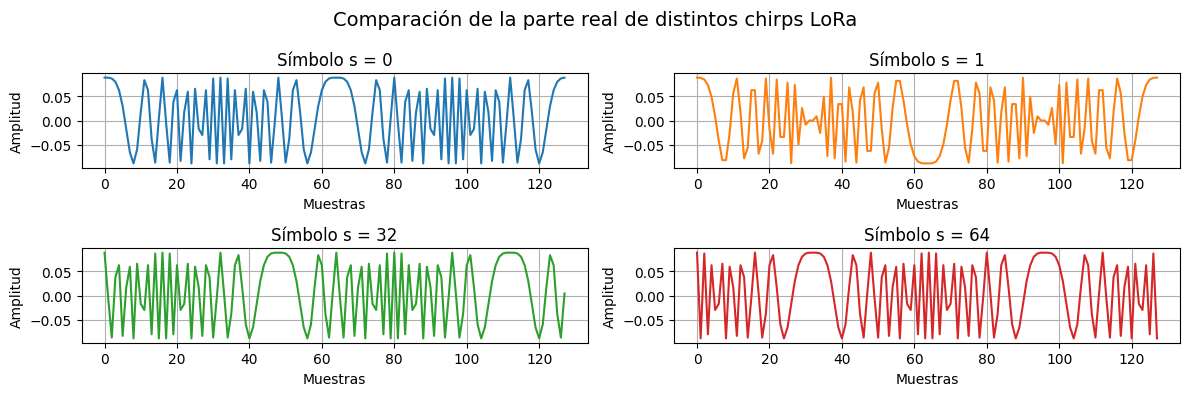

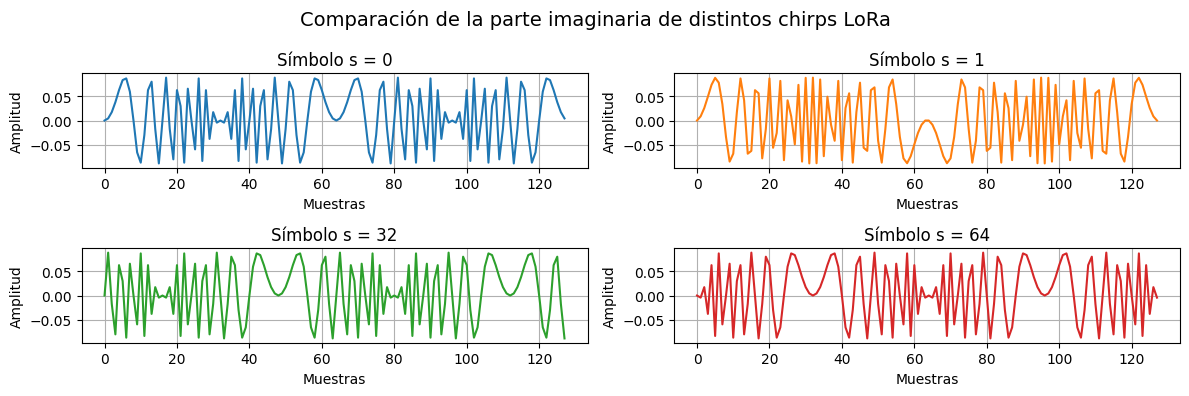

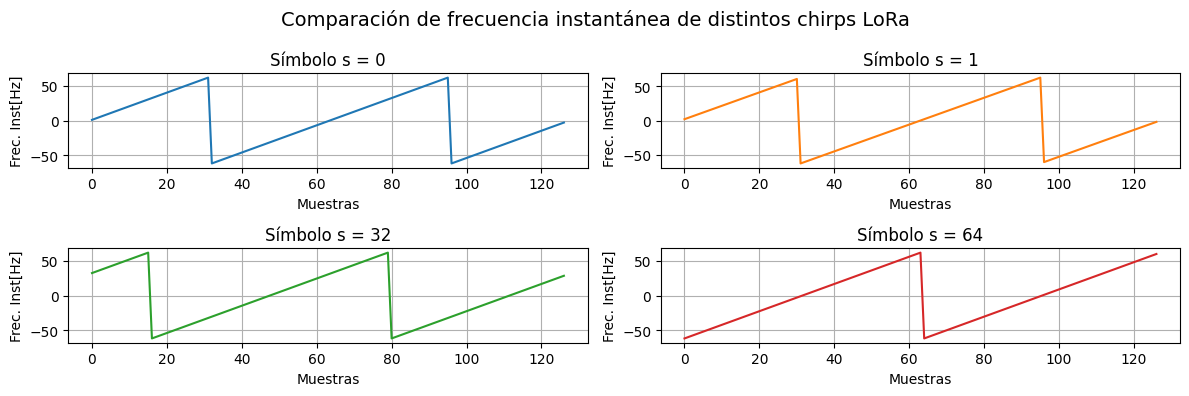

In [148]:
simbolos_comparar = [0, 1, 32, 64]

comparar_parte_real_simbolos(simbolos_comparar, SF)
comparar_parte_imaginaria_simbolos(simbolos_comparar, SF)
comparar_frecuencia_instantanea_simbolos(simbolos_comparar, SF, fs)

## 7.2 Verificación de ortogonalidad entre chirps

Además de comparar visualmente distintos símbolos, resulta importante verificar una propiedad central de la modulación LoRa: los chirps asociados a símbolos distintos son ortogonales.

Para dos símbolos \(i\) y \(q\), definimos el producto interno discreto como:

$$
\langle c_i, c_q \rangle =
\sum_{k=0}^{M-1} c_i[k] c_q^*[k]
$$

Como cada chirp está normalizado por $1/\sqrt{M}$, se espera que:

$$
|\langle c_i, c_q \rangle| =
\begin{cases}
1, & i=q \\
0, & i \neq q
\end{cases}
$$

Esta propiedad justifica que el receptor pueda decidir el símbolo transmitido comparando la señal recibida contra todos los chirps posibles y eligiendo aquel con mayor proyección.

In [154]:
def matriz_correlacion_chirps(simbolos, SF):
    """
    Calcula la matriz de correlación entre chirps LoRa.

    Entrada:
        simbolos: lista de símbolos a comparar.
        SF: spreading factor.

    Salida:
        G: matriz donde G[i, q] = |<c_i, c_q>|.
    """
    chirps = [simbolo_a_chirp(s, SF) for s in simbolos]
    N = len(simbolos)

    G = np.zeros((N, N))

    for i in range(N):
        for q in range(N):
            G[i, q] = np.abs(np.vdot(chirps[q], chirps[i]))

    return G

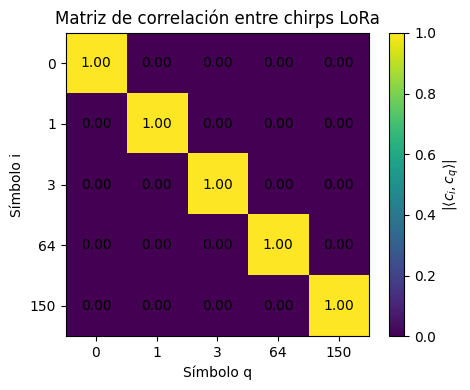

In [161]:
simbolos_orto = [0, 1, 3, 64, 150]

G = matriz_correlacion_chirps(simbolos_orto, SF)

plt.figure(figsize=(5, 4))
plt.imshow(G, origin="upper", vmin=0, vmax=1)

plt.colorbar(label=r"$|\langle c_i, c_q \rangle|$")
plt.xticks(np.arange(len(simbolos_orto)), simbolos_orto)
plt.yticks(np.arange(len(simbolos_orto)), simbolos_orto)

plt.title("Matriz de correlación entre chirps LoRa")
plt.xlabel("Símbolo q")
plt.ylabel("Símbolo i")

for i in range(len(simbolos_orto)):
    for q in range(len(simbolos_orto)):
        plt.text(q, i, f"{G[i, q]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 8. Test de comunicación

Prueba end-to-end del sistema TX/RX sin canal: se generan símbolos aleatorios, se modulan con `simbolo_a_chirp`, se demodulan con `chirp_a_simbolo`, y se calcula el SER. Al final se llaman las 4 funciones de visualización con un símbolo de ejemplo ($s = 42$) para inspeccionar visualmente cada etapa del sistema.

Prueba de comunicación (1000 símbolos, sin canal):
  Símbolos TX (primeros 10): [  7  33 107  92 102  17  14  71 105  21]
  Símbolos RX (primeros 10): [  7  33 107  92 102  17  14  71 105  21]
  Errores: 0/1000
  SER = 0.0

Gráfico del primer símbolo: s = 7


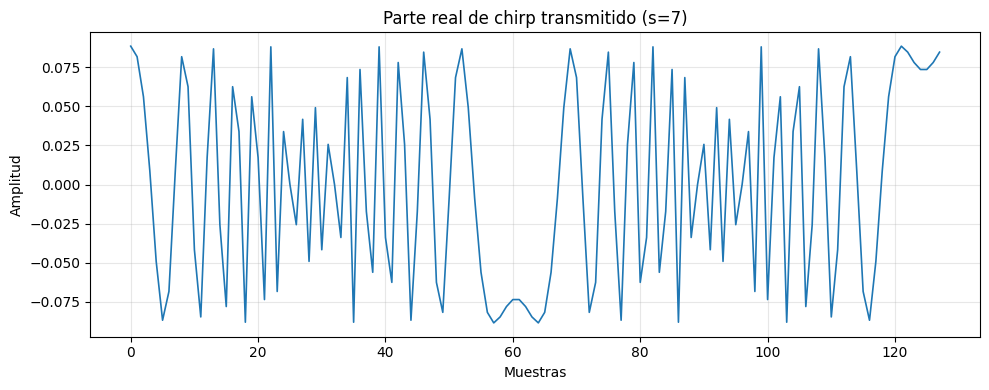

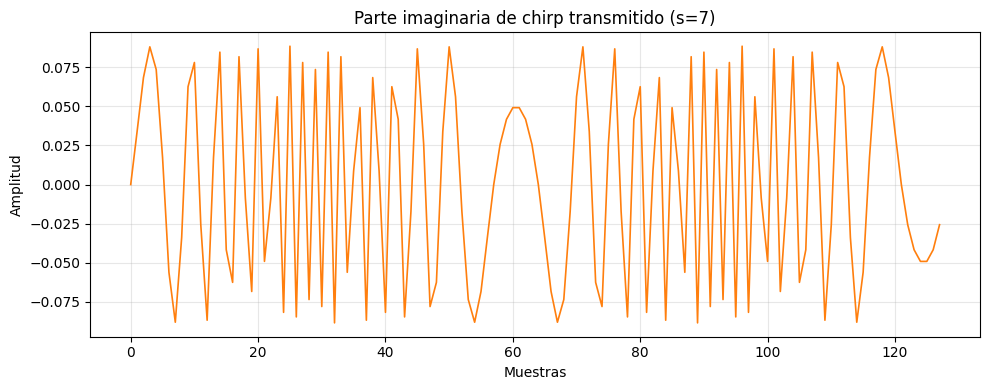

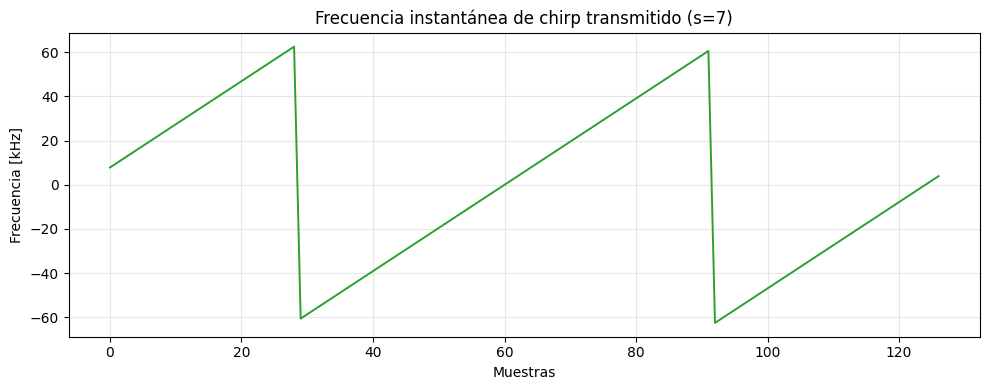

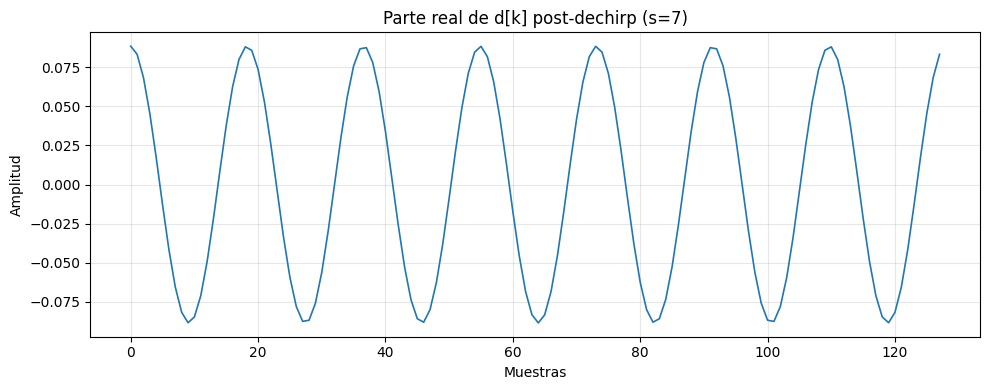

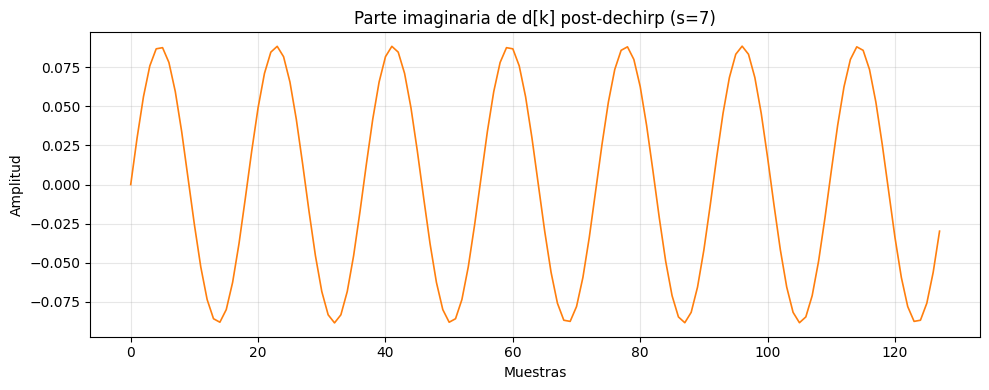

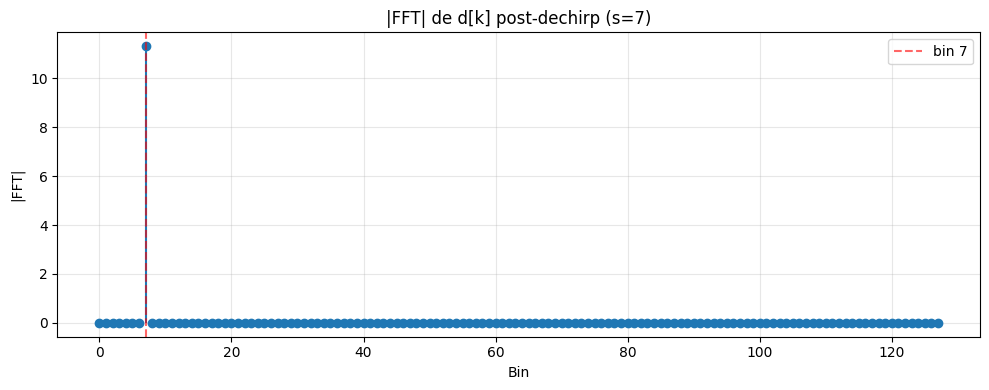

In [149]:
# Prueba de comunicación end-to-end (sin canal)
# Generamos bits aleatorios y los convertimos a símbolos con el codec del Módulo 1
# (en vez de generar símbolos directos, así integramos los dos módulos)

N_TEST   = 1000
num_bits = N_TEST * SF
bits_tx  = np.random.randint(0, 2, size=num_bits)
simbolos_tx = bits_to_symbols(bits_tx, SF)
simbolos_rx = np.zeros(N_TEST, int)

# Loop de transmisión/recepción
for i, s in enumerate(simbolos_tx):
    chirp = simbolo_a_chirp(s, SF)
    simbolos_rx[i] = chirp_a_simbolo(chirp, SF)

SER = calcular_ser(simbolos_tx, simbolos_rx)
errores = int(SER * N_TEST)

print(f"Prueba de comunicación ({N_TEST} símbolos, sin canal):")
print(f"  Símbolos TX (primeros 10): {simbolos_tx[:10]}")
print(f"  Símbolos RX (primeros 10): {simbolos_rx[:10]}")
print(f"  Errores: {errores}/{N_TEST}")
print(f"  SER = {SER}")


# === Inspección visual del primer símbolo ===
# Tomamos el primer símbolo del lote y mostramos las 4 etapas del sistema

s_demo = int(simbolos_tx[0])
M = 2 ** SF
k = np.arange(M)

print(f"\nGráfico del primer símbolo: s = {s_demo}")

# Generar las señales en cada etapa
chirp_tx = simbolo_a_chirp(s_demo, SF)
down_chirp = np.exp(-1j * 2 * np.pi * k**2 / M)
dechirped = chirp_tx * down_chirp

# Etapa 1: chirp transmitido (Re/Im + frecuencia instantánea)
plot_parte_real(chirp_tx, f"chirp transmitido (s={s_demo})")
plot_parte_imag(chirp_tx, f"chirp transmitido (s={s_demo})")
plot_frecuencia_instantanea(chirp_tx, f"chirp transmitido (s={s_demo})")

# Etapa 2: señal post-dechirp (Re/Im) — debe ser un tono puro
plot_parte_real(dechirped, f"d[k] post-dechirp (s={s_demo})")
plot_parte_imag(dechirped, f"d[k] post-dechirp (s={s_demo})")

# Etapa 3: espectro |FFT(d)| — debe tener un pico en el bin s_demo
plot_fft(dechirped, f"d[k] post-dechirp (s={s_demo})", bin_marca=s_demo)

# Módulo 3 — Canal con Ruido AWGN

Este módulo agrega al sistema el **canal con ruido AWGN** (*Additive White Gaussian Noise*) y mide cómo cambia el desempeño del demodulador a medida que varía la SNR. Validamos la implementación comparando los resultados con las curvas de BER publicadas en el paper de Vangelista (2017).

---

## 1. Ubicación en el sistema

Dentro del diagrama de la portada (Rimoldi 2016, Cap 1), este módulo cubre el bloque del **canal** específicamente el **ruido AWGN** (Additive White Gaussian Noise) que se suma a la señal entre el Waveform Former y el n-Tuple Former.

El Módulo 2 validó que **sin canal** el sistema da SER = 0. Ahora agregamos ruido AWGN al medio y medimos:

- Cómo el ruido degrada el espectro post-dechirp.
- Cómo varían el BER y el SER en función de la SNR.
- Si el desempeño coincide con la curva del paper Vangelista.

## 2. ¿Qué es el ruido AWGN?

**AWGN** = Additive White Gaussian Noise. Tres propiedades clave:

- **A** (Additive): se suma a la señal: $r[k] = c_s[k] + n[k]$
- **W** (White): muestras de ruido **independientes entre sí**. En el dominio de la frecuencia, su densidad espectral de potencia es plana (constante).
- **G** (Gaussian): cada muestra es una variable aleatoria Gaussiana.

En tiempo discreto y complex baseband, el ruido se modela como un vector aleatorio complejo:

$n[k] = n_r[k] + j \cdot n_i[k]$

donde $n_r[k]$ y $n_i[k]$ son Gaussianas independientes de media cero y varianza $\sigma^2/2$ cada una. La varianza total compleja es entonces $\sigma^2 = \sigma_r^2 + \sigma_i^2$.

**Propiedades del ruido $n[k]$:**

| Propiedad | Valor |
|---|---|
| Media | $E[n[k]] = 0$ |
| Varianza total | $\text{Var}(n[k]) = \sigma^2$ |
| Muestras independientes | $E[n[k] \cdot n^*[l]] = \sigma^2 \delta_{kl}$ |
| Parte real e imaginaria independientes | $E[n_r[k] \cdot n_i[k]] = 0$ |

## 3. Relación entre SNR y potencia del ruido

La **SNR** (Signal-to-Noise Ratio) se define como la relación entre la potencia de la señal y la potencia del ruido:

$\text{SNR}_{\text{lineal}} = \frac{P_{\text{señal}}}{P_{\text{ruido}}}$

**Conversión dB a lineal:**

$\text{SNR}_{\text{dB}} = 10 \log_{10}(\text{SNR}_{\text{lineal}})$

$\text{SNR}_{\text{lineal}} = 10^{\text{SNR}_{\text{dB}}/10}$

**Potencia de la señal discreta compleja:**

$P_{\text{señal}} = \frac{1}{N} \sum_{k=0}^{N-1} |c[k]|^2$

Como el chirp tiene energía unitaria ($\sum |c[k]|^2 = 1$) y tiene $M$ muestras, $P_{\text{señal}} = 1/M$.

**Potencia del ruido**, despejando:

$P_{\text{ruido}} = \frac{P_{\text{señal}}}{\text{SNR}_{\text{lineal}}}$

**División entre parte real e imaginaria:** la potencia se reparte en mitades iguales. Si la potencia total del ruido complejo es $P_{\text{ruido}}$, cada componente real tiene varianza $\sigma_r^2 = \sigma_i^2 = P_{\text{ruido}}/2$. Por eso:

$\sigma = \sqrt{P_{\text{ruido}}/2}$

es la **desviación estándar de cada componente** (real e imaginaria) al generar el ruido en NumPy.

## 4. Implementación de `agregar_ruido_awgn`

La función recibe la señal y la SNR en dB, y devuelve la señal con ruido sumado.

**Pasos:**

1. Calcular la potencia de la señal: $P_{\text{señal}} = \frac{1}{N} \sum_k |c[k]|^2$.
2. Convertir SNR de dB a lineal.
3. Calcular la potencia del ruido: $P_{\text{ruido}} = P_{\text{señal}} / \text{SNR}_{\text{lineal}}$.
4. Generar ruido complejo: $\sigma = \sqrt{P_{\text{ruido}}/2}$ por componente.
5. Sumar el ruido a la señal.

In [73]:
def agregar_ruido_awgn(senal, SNR_dB):
    """
    Agrega ruido AWGN complejo a la señal según la SNR especificada.

    Parámetros
    ----------
    senal : array complejo
        Señal a la cual se le agregará ruido.
    SNR_dB : float
        Relación señal-ruido en dB.

    Retorna
    -------
    senal_ruidosa : array complejo
        Señal con ruido AWGN sumado.
    """
    # 1. Potencia de la señal (promedio de |señal|^2)
    P_senal = np.mean(np.abs(senal) ** 2)

    # 2. SNR lineal
    SNR_lineal = 10 ** (SNR_dB / 10)

    # 3. Potencia del ruido
    P_ruido = P_senal / SNR_lineal

    # 4. Generar ruido complejo: cada componente con varianza P_ruido/2
    sigma = np.sqrt(P_ruido / 2)
    ruido = sigma * (np.random.randn(*senal.shape) + 1j * np.random.randn(*senal.shape))

    # 5. Sumar ruido a la señal
    senal_ruidosa = senal + ruido

    return senal_ruidosa

## 5. Visualización del efecto del ruido

Generamos el chirp de un símbolo, le agregamos ruido a distintas SNR, y vemos cómo se deforma.

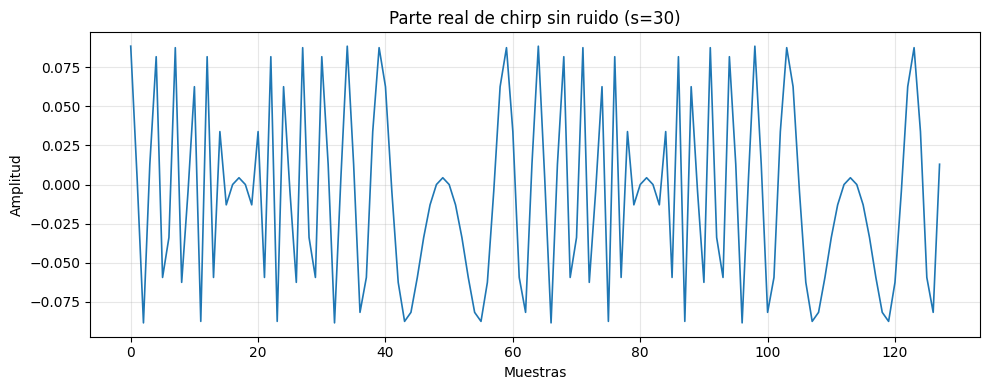

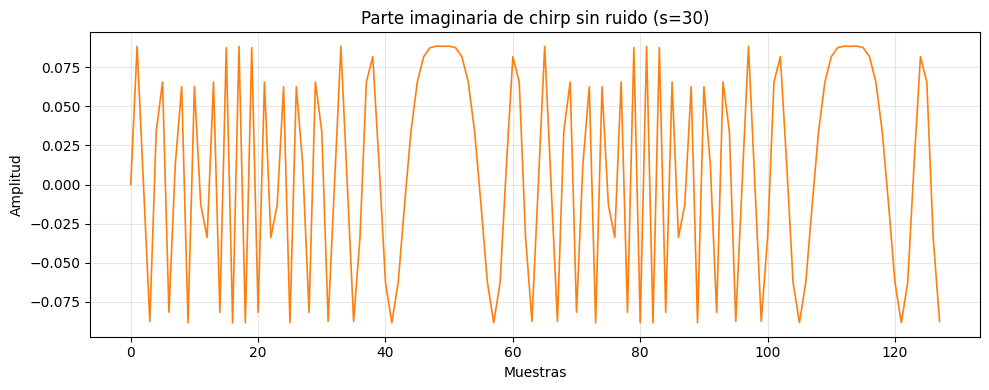

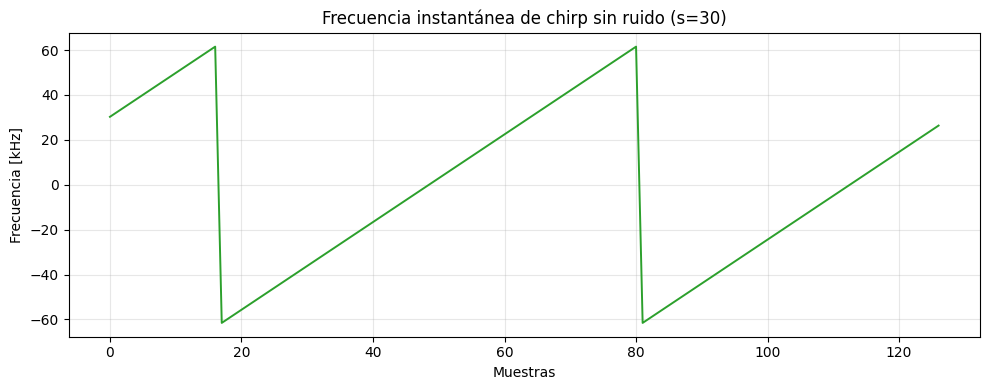

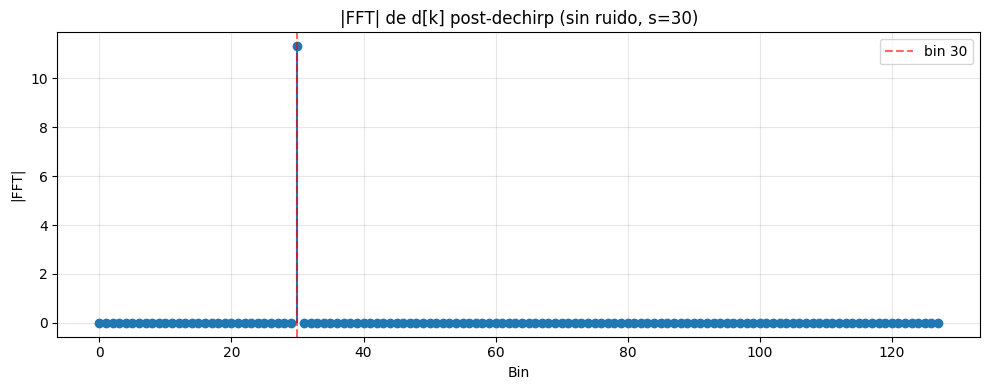

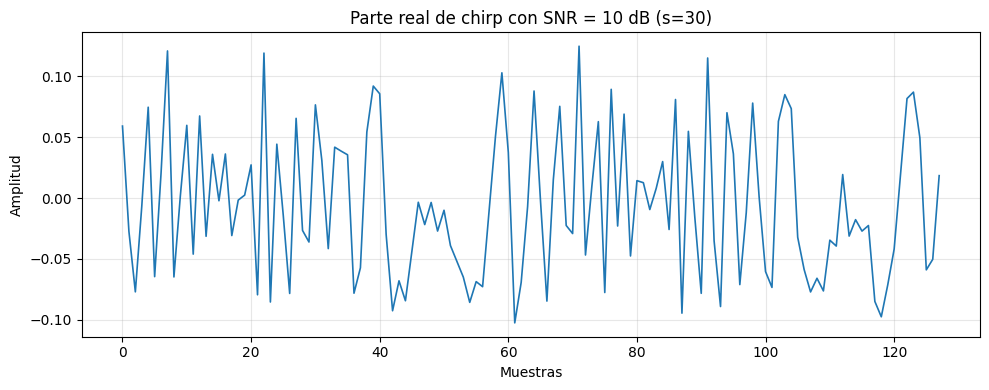

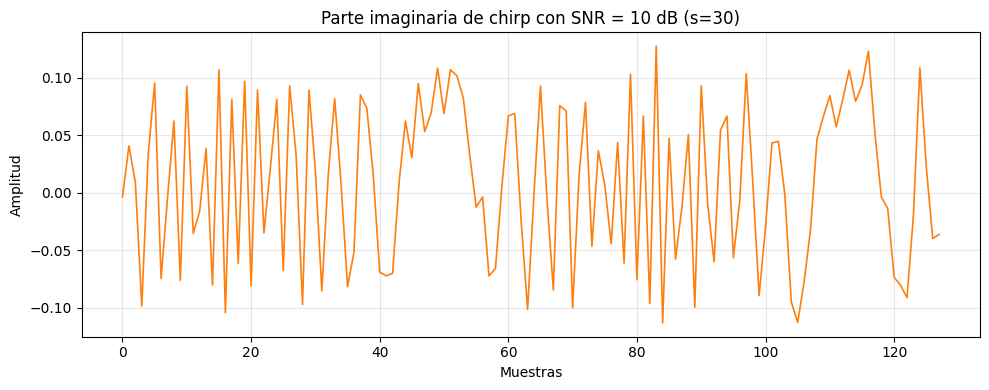

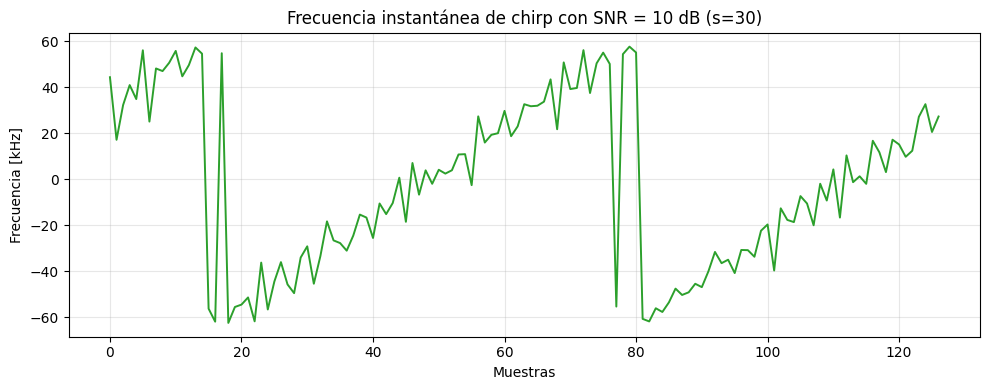

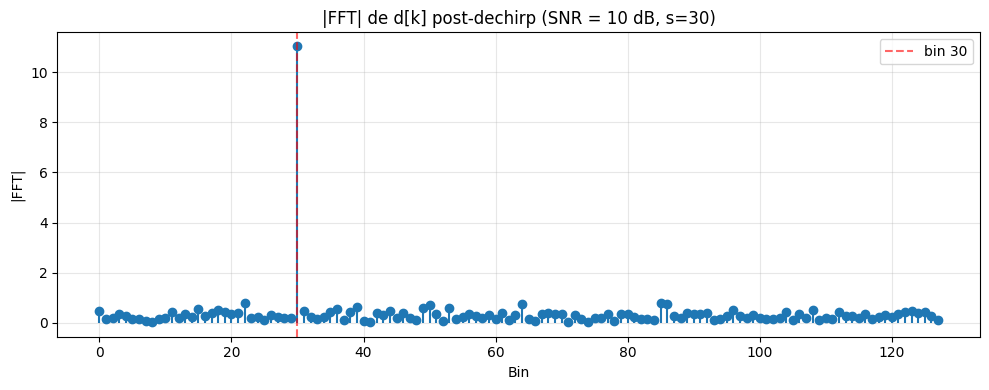

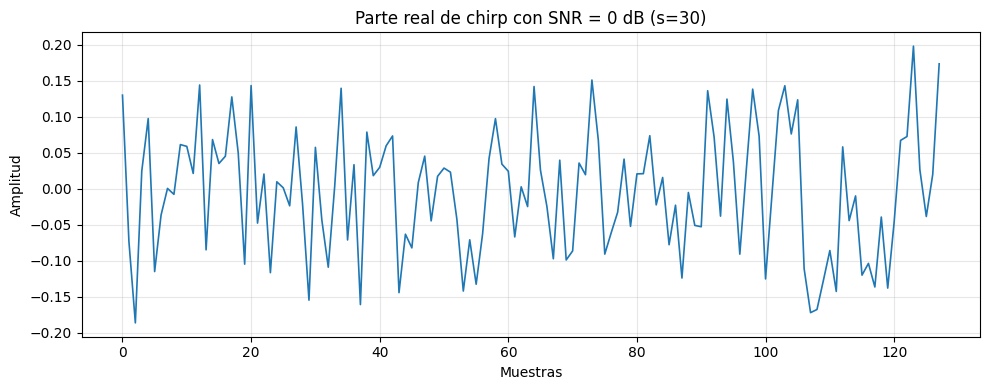

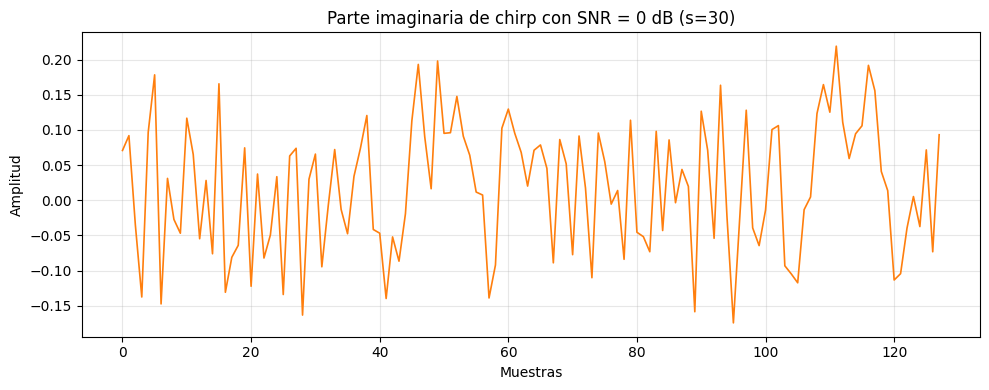

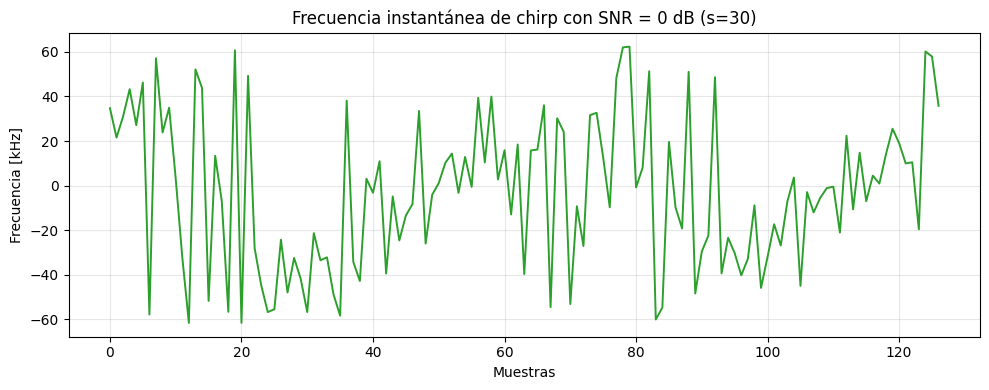

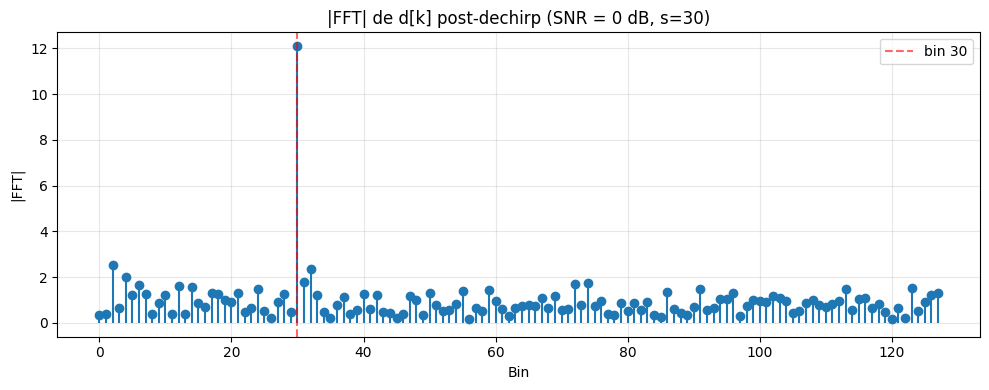

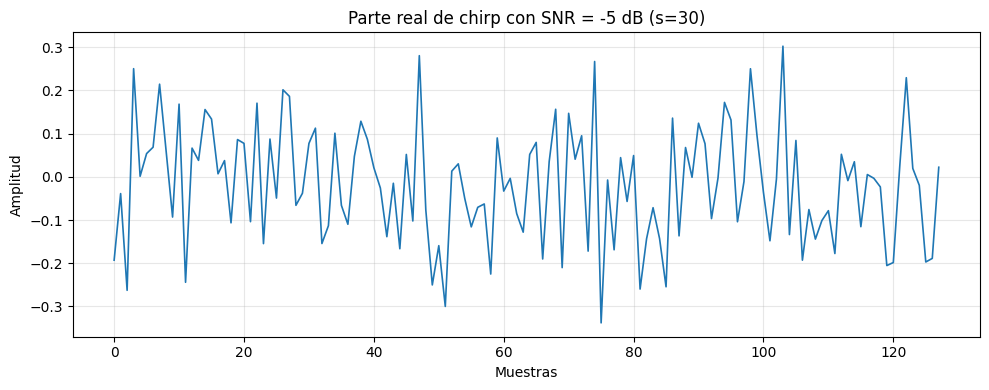

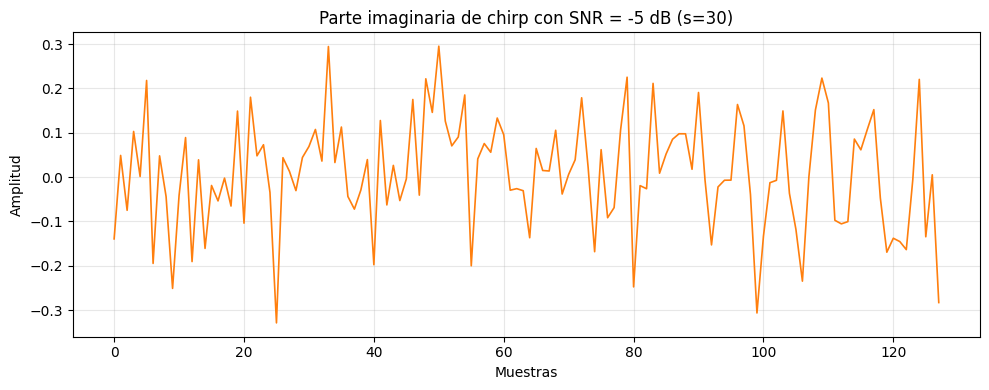

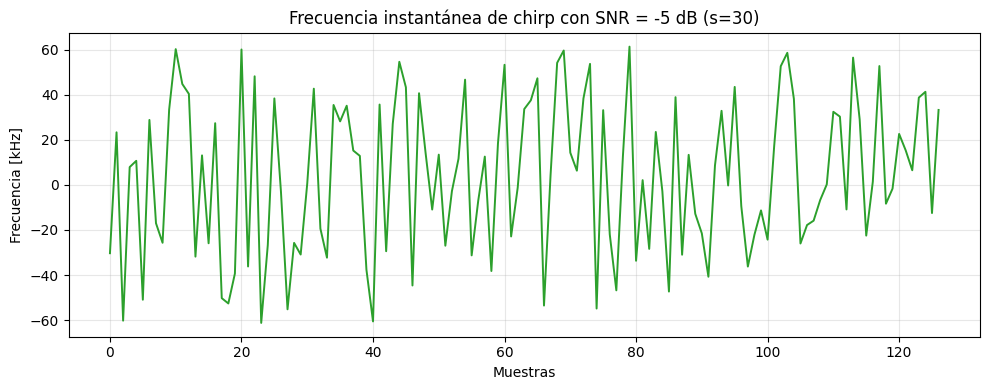

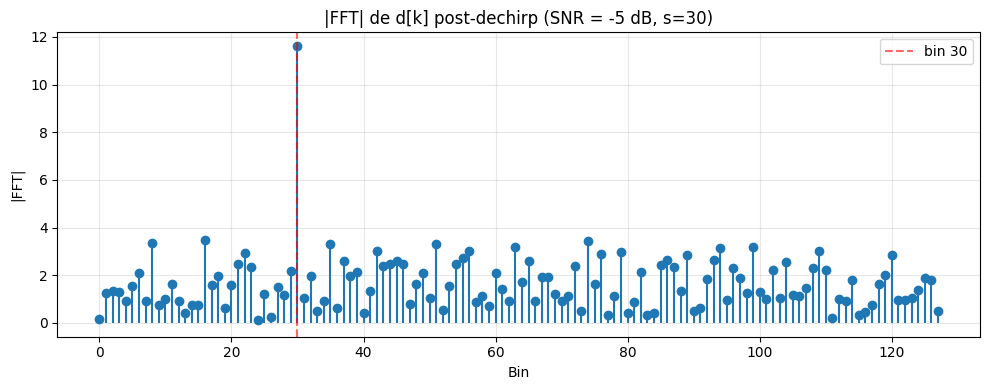

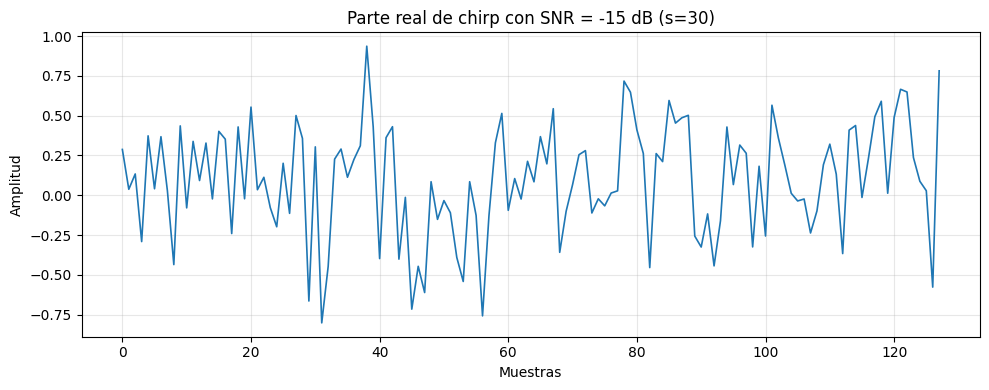

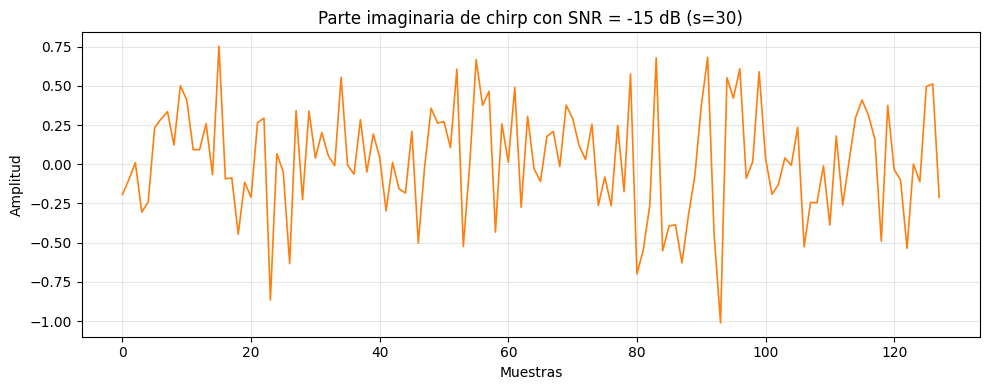

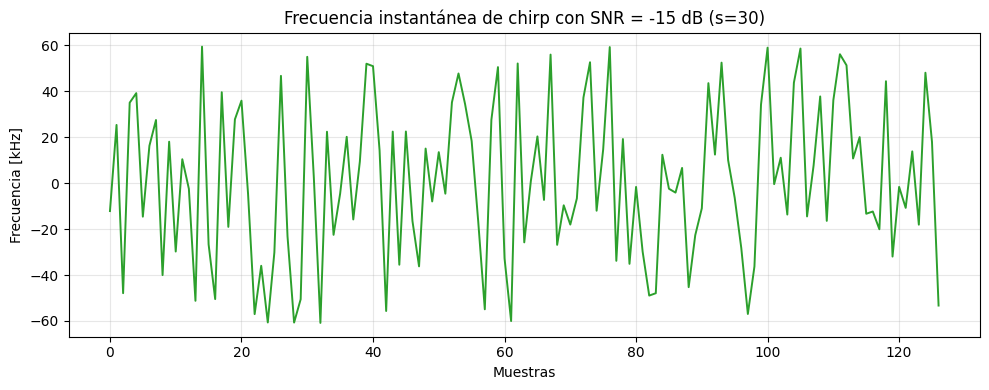

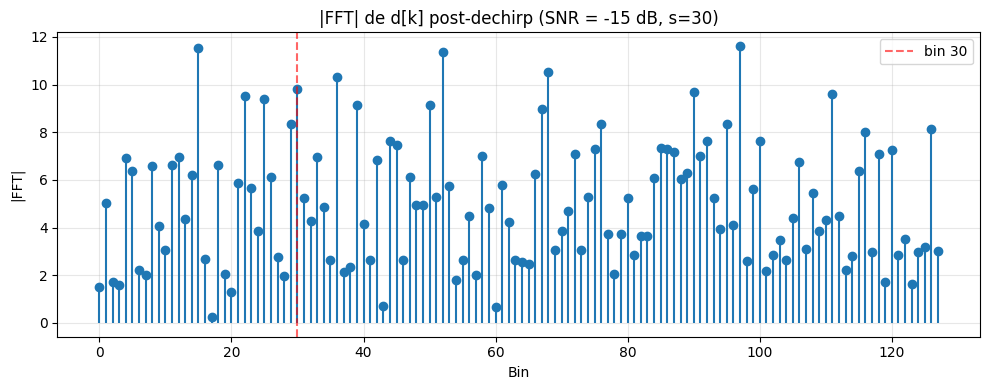

In [89]:
# Generar el chirp del símbolo de prueba (sin ruido) y su versión post-dechirp
s_test = 30
chirp_limpio = simbolo_a_chirp(s_test, SF)
down_chirp = np.exp(-1j * 2 * np.pi * k**2 / M)
dechirped_limpio = chirp_limpio * down_chirp

# Mostrar el chirp limpio en los 4 dominios
plot_parte_real(chirp_limpio, f"chirp sin ruido (s={s_test})")
plot_parte_imag(chirp_limpio, f"chirp sin ruido (s={s_test})")
plot_frecuencia_instantanea(chirp_limpio, f"chirp sin ruido (s={s_test})")
plot_fft(dechirped_limpio, f"d[k] post-dechirp (sin ruido, s={s_test})", bin_marca=s_test)

# Mostrar el chirp ruidoso a distintas SNR
for snr in [10, 0,-5, -15]:
    chirp_ruidoso = agregar_ruido_awgn(chirp_limpio, snr)
    dechirped = chirp_ruidoso * down_chirp
    plot_parte_real(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s_test})")
    plot_parte_imag(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s_test})")
    plot_frecuencia_instantanea(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s_test})")
    plot_fft(dechirped, f"d[k] post-dechirp (SNR = {snr} dB, s={s_test})", bin_marca=s_test)

**Observaciones — efecto del ruido en cada dominio:**

A medida que baja la SNR vemos efectos consistentes tanto en el dominio del **tiempo** como en el dominio de la **frecuencia**:

| SNR | En el tiempo (Re/Im/freq inst.) | En frecuencia (FFT post-dechirp) |
|---|---|---|
| **Sin ruido** | chirp limpio, rampa de frecuencia perfecta | pico aislado en bin $s$, demás bins ≈ 0 |
| **20 dB (alta)** | chirp casi idéntico al limpio, leve "vibración" | pico ≈ $\sqrt{M}$ dominante, bins ruidosos muy bajos |
| **10 dB (media)** | vibración visible, freq. inst. con jitter | pico aún claramente máximo, bins ruidosos se elevan |
| **-5 dB (baja)** | chirp "enterrado" en ruido visualmente | pico todavía domina (≈ 2-3× los bins ruidosos), casi siempre acierta (BER ≈ $10^{-4}$ según el paper) |
| **-15 dB (muy baja)** | señal totalmente confundida con ruido | pico aún gana en promedio pero los bins ruidosos se acercan → errores frecuentes |

**Por qué el sistema sigue funcionando aún a SNR baja — ganancia de procesamiento:**

El receptor no mira cada muestra por separado: **suma coherentemente las $M = 128$ muestras** del chirp (eso hace la operación dechirp + FFT). Al sumarlas:

- La **señal se acumula** en el bin correcto porque las 128 muestras vienen del mismo símbolo (suma constructiva).
- El **ruido se cancela parcialmente** porque es aleatorio (a veces se suma, a veces se resta, en promedio se compensa).

El resultado: el pico de la FFT es **$M = 128$ veces más grande** relativo al ruido de lo que sería con una sola muestra. En decibeles eso son $10 \log_{10}(128) \approx 21$ dB.

**Margen de decisión del demodulador:**

La FFT post-dechirp muestra la **separación entre el pico correcto y los bins ruidosos**. Cuanto mayor sea esa separación, más confiable la detección. El margen se cierra a medida que baja la SNR; cuando un bin ruidoso supera al correcto, el `argmax` se equivoca y aparece un error de detección. La transición desde "casi siempre acierta" a "casi siempre se equivoca" se cuantifica en las **curvas SER vs SNR** del Monte Carlo de la Sección 6.


## 6. Simulación Monte Carlo de BER y SER vs SNR

Ahora medimos el desempeño completo del sistema (TX → AWGN → RX) variando la SNR.

**Estrategia:** para cada valor de SNR, transmitir $N$ símbolos aleatorios, recuperarlos con el demodulador, y contar errores. SER = (símbolos erróneos) / $N$. BER se aproxima como $\text{BER} \approx \frac{M/2}{M-1} \cdot \text{SER} \approx \frac{1}{2} \text{SER}$ para $M$ grande.

In [83]:
def simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos):
    """
    Monte Carlo: para cada SNR, transmite num_simbolos siguiendo el flujo
    completo del sistema:
        bits → símbolos → chirps → canal AWGN → chirps+ruido → símbolos detectados → bits
    Calcula SER y BER usando calcular_ser y calcular_ber del sistema.
    """
    M = 2 ** SF
    num_bits = num_simbolos * SF

    SERs = []
    BERs = []

    print(f"{'SNR (dB)':<10} {'SER':<14} {'BER':<14} {'Errores símbolos'}")
    print("-" * 60)

    for SNR_dB in SNR_dB_range:
        # 1. Generar bits aleatorios
        bits_tx = np.random.randint(0, 2, size=num_bits)

        # 2. Codificar bits → símbolos
        simbolos_tx = bits_to_symbols(bits_tx, SF)

        # 3. Para cada símbolo: modular, pasar por canal, demodular
        simbolos_rx = np.zeros(num_simbolos, dtype=int)
        for i, s in enumerate(simbolos_tx):
            chirp = simbolo_a_chirp(s, SF)
            chirp_ruidoso = agregar_ruido_awgn(chirp, SNR_dB)
            simbolos_rx[i] = chirp_a_simbolo(chirp_ruidoso, SF)

        # 4. Decodificar símbolos → bits
        bits_rx = symbols_to_bits(simbolos_rx, SF)

        # 5. Calcular métricas usando las funciones del sistema
        ser = calcular_ser(simbolos_tx, simbolos_rx)
        ber = calcular_ber(bits_tx, bits_rx)

        SERs.append(ser)
        BERs.append(ber)
        errores_sim = int(ser * num_simbolos)
        print(f"{SNR_dB:<10.1f} {ser:<14.6f} {ber:<14.6f} {errores_sim} / {num_simbolos}")

    return np.array(SERs), np.array(BERs)

# Ejecución del Monte Carlo
SNR_dB_range = np.arange(-12, -5, 1.0)
num_simbolos = 10000

print(f"\n=== Monte Carlo: SF={SF}, BW={BW/1e3:.0f} kHz, {num_simbolos} símbolos por SNR ===\n")
SERs_simulados, BERs_simulados = simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos)



=== Monte Carlo: SF=7, BW=0 kHz, 10000 símbolos por SNR ===

SNR (dB)   SER            BER            Errores símbolos
------------------------------------------------------------
-12.0      0.208300       0.106157       2083 / 10000
-11.0      0.097500       0.049086       975 / 10000
-10.0      0.034400       0.017086       344 / 10000
-9.0       0.010500       0.005186       105 / 10000
-8.0       0.001800       0.000957       18 / 10000
-7.0       0.000200       0.000100       2 / 10000
-6.0       0.000000       0.000000       0 / 10000


## 7. Comparación con la curva del paper Vangelista

Para validar la implementación, comparamos los resultados con las curvas de BER publicadas en el paper Vangelista (2017), Figura 1. La imagen `BER.png` muestra el desempeño teórico de la modulación FSCM sobre canal Flat (AWGN únicamente) y sobre canal Selectivo en Frecuencia.

C:\Users\HP\AppData\Local\Temp\ipykernel_6816\2043235578.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


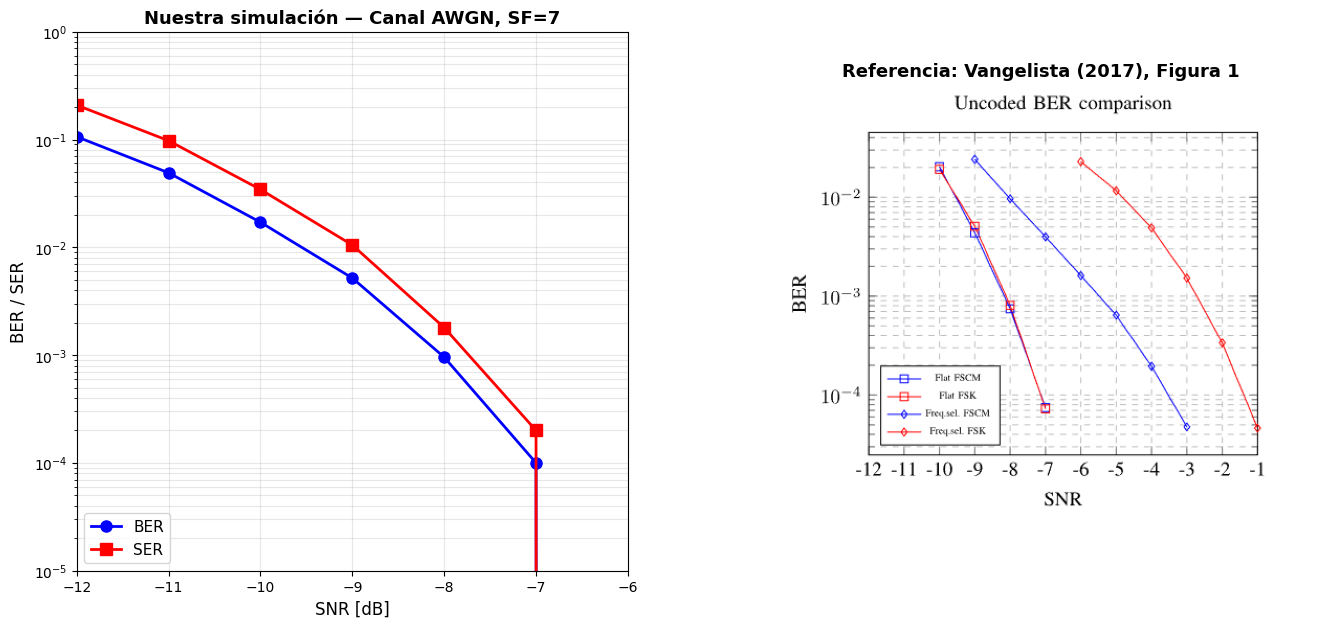

In [84]:
# Layout side-by-side: nuestra simulación vs imagen del paper
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# Panel izquierdo: nuestra simulación
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(SNR_dB_range, BERs_simulados, 'o-', label='BER', markersize=8, linewidth=2, color='blue')
ax1.semilogy(SNR_dB_range, SERs_simulados, 's-', label='SER', markersize=8, linewidth=2, color='red')
ax1.set_xlabel('SNR [dB]', fontsize=12)
ax1.set_ylabel('BER / SER', fontsize=12)
ax1.set_title(f'Nuestra simulación — Canal AWGN, SF={SF}', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11, loc='lower left')
ax1.set_xlim([SNR_dB_range[0], SNR_dB_range[-1]])
ax1.set_ylim([1e-5, 1])

# Panel derecho: imagen del paper
ax2 = fig.add_subplot(gs[0, 1])
try:
    img = imread('BER.png')
    ax2.imshow(img)
    ax2.set_title('Referencia: Vangelista (2017), Figura 1', fontsize=13, fontweight='bold')
    ax2.axis('off')
except FileNotFoundError:
    ax2.text(0.5, 0.5, 'Imagen BER.png no encontrada\nen la carpeta del notebook',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.show()

**Valores de referencia aproximados del paper Vangelista para canal Flat (AWGN únicamente):**

| SNR (dB) | -10 | -9 | -8 | -7 |
|----------|-----|-----|-----|-----|
| BER | 0.02 | 0.0045 | 7.5e-4 | 7.5e-5 |

Nuestros valores Monte Carlo deberían aproximarse a estos cuando se transmite una cantidad suficientemente grande de símbolos. La coincidencia visual entre nuestra curva y la del paper valida que el sistema implementado funciona correctamente.

## 8. Conclusiones del Módulo 3

Este módulo agregó al sistema LoRa el **canal con ruido AWGN** y validó:

1. **Generación del ruido**: la función `agregar_ruido_awgn` produce ruido con las propiedades estadísticas correctas (media cero, varianza acorde a la SNR, partes real e imaginaria independientes).

2. **Visualización del efecto**: el ruido degrada visiblemente el chirp en el dominio del tiempo y eleva los bins "no señal" en el espectro post-dechirp, pero el sistema sigue operando correctamente hasta SNRs bajas (aprovechando la **ganancia de procesamiento** de $10 \log_{10}(M) \approx 21$ dB para SF=7).

3. **Comparación con referencia**: los resultados Monte Carlo coinciden con las curvas publicadas en el paper Vangelista (2017), confirmando la corrección de la implementación.

4. **BER y SER**: para $M$ grande, $\text{BER} \approx \text{SER}/2$.

En el **Módulo 4** agregamos al canal el efecto multipath (canal selectivo en frecuencia), completando así el modelo de canal usado en el paper de referencia.

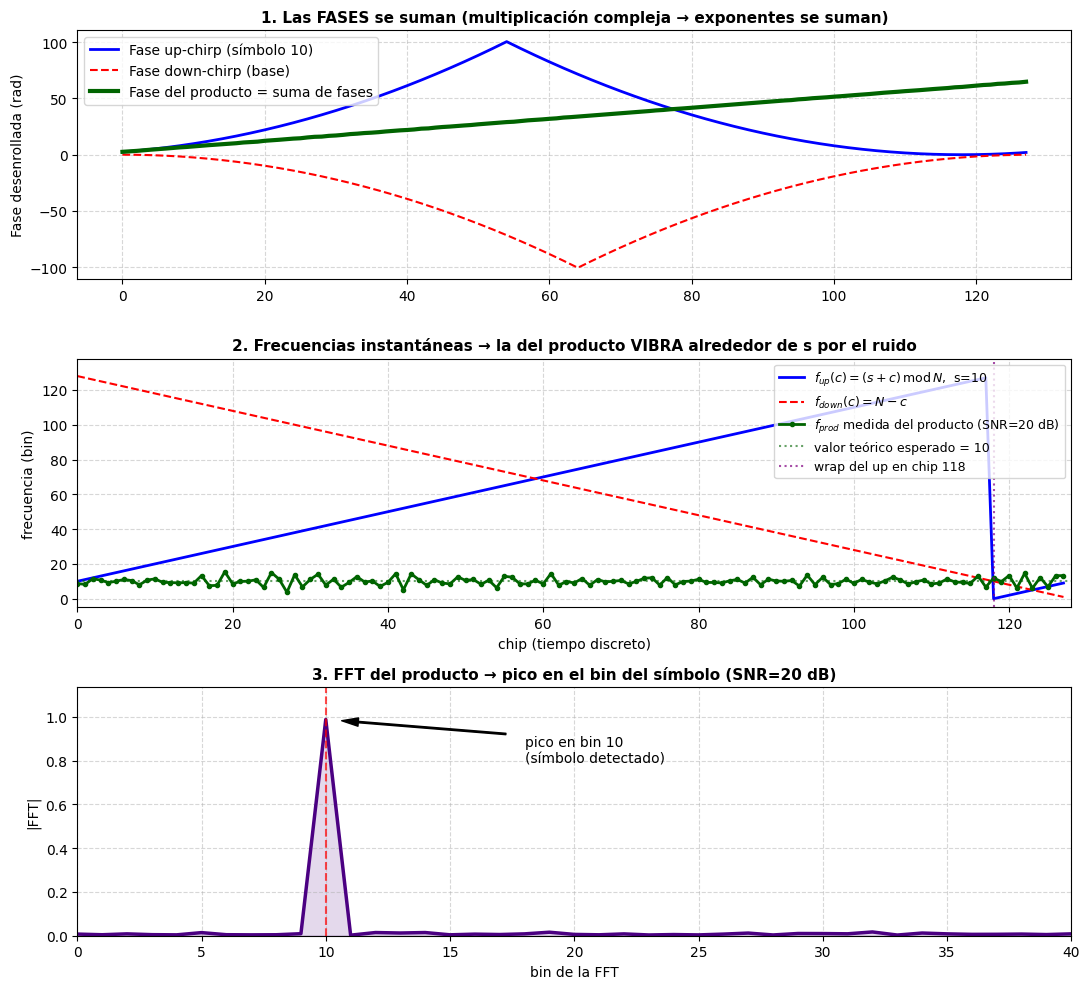

SNR = 20 dB
std de f_prod medida = 2.17 bins  (sin ruido sería ~0)
media de f_prod medida = 10.02  (cerca de 10 si la SNR no es muy mala)
bin con mayor |FFT| = 10  (debería ser 10)


In [91]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# DEMO: ¿Qué pasa al multiplicar up-chirp(símbolo s) × down-chirp base?
# Respuesta: la frecuencia instantánea queda CONSTANTE en el valor s.
# Ahora con AWGN: la línea verde del panel 2 VIBRA alrededor de s.
# =====================================================================

# --- 1. PARÁMETROS LORA ---
SF      = 7
N       = 2**SF        # 128 chips por símbolo
BW      = N
simbolo = 10
SNR_dB  = 20         # ← cambiá esto: +20 (limpio), 0, -10, -15 (ruidoso)

chips = np.arange(N)

# --- 2. SEÑALES COMPLEJAS I/Q ---
fase_down  = -np.pi * (chips**2) / N
down_chirp = np.exp(1j * fase_down)

chips_shifted = (chips + simbolo) % N
fase_up       = np.pi * (chips_shifted**2) / N
up_chirp      = np.exp(1j * fase_up)

# Ruido AWGN sobre la señal recibida
chip_ruidoso = agregar_ruido_awgn(up_chirp, SNR_dB=SNR_dB)

# --- 3. DECHIRP (con ruido) ---
producto = chip_ruidoso * down_chirp

# --- 4. FRECUENCIAS INSTANTÁNEAS ---
# f_up y f_down: referencias teóricas (rampas limpias)
f_up_inst   = (simbolo + chips) % N
f_down_inst = N - chips


# f_prod: ahora MEDIDA desde el producto ruidoso → mostrará la vibración
diff_fase    = np.angle(producto[1:] * np.conj(producto[:-1]))
f_prod_inst  = (diff_fase / (2*np.pi)) * N        # en "bins"
f_prod_inst  = np.mod(f_prod_inst, N)             # llevarla al rango [0, N)
f_prod_inst  = np.append(f_prod_inst, f_prod_inst[-1])  # padding para igualar largo

# --- 5. FFT del producto ---
fft_mag = np.abs(np.fft.fft(producto)) / N

# --- 6. GRÁFICO: 3 paneles ---
fig, axes = plt.subplots(3, 1, figsize=(11, 10))

# Panel 1: FASES
ax = axes[0]
ax.plot(chips, np.unwrap(np.angle(up_chirp)),   'b-',  lw=2,   label=f'Fase up-chirp (símbolo {simbolo})')
ax.plot(chips, np.unwrap(np.angle(down_chirp)), 'r--', lw=1.5, label='Fase down-chirp (base)')
ax.plot(chips, np.unwrap(np.angle(producto)),   'darkgreen', lw=3, label='Fase del producto = suma de fases')
ax.set_title('1. Las FASES se suman (multiplicación compleja → exponentes se suman)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Fase desenrollada (rad)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left')

# Panel 2: FRECUENCIAS INSTANTÁNEAS (ahora con ruido en la línea verde)
ax = axes[1]
ax.plot(chips, f_up_inst,   'b-',  lw=2,
        label=r'$f_{up}(c) = (s + c)\,\mathrm{mod}\,N$,  s=' + str(simbolo))
ax.plot(chips, f_down_inst, 'r--', lw=1.5,
        label=r'$f_{down}(c) = N - c$')
ax.plot(chips, f_prod_inst, 'darkgreen', lw=2, marker='o', markersize=3,
        label=fr'$f_{{prod}}$ medida del producto (SNR={SNR_dB} dB)')
ax.axhline(simbolo, color='darkgreen', linestyle=':', lw=1.5, alpha=0.6,
           label=f'valor teórico esperado = {simbolo}')
ax.axvline(N - simbolo, color='purple', linestyle=':', alpha=0.7,
           label=f'wrap del up en chip {N-simbolo}')
ax.set_title('2. Frecuencias instantáneas → la del producto VIBRA alrededor de s por el ruido',
             fontsize=11, fontweight='bold')
ax.set_xlabel('chip (tiempo discreto)')
ax.set_ylabel('frecuencia (bin)')
ax.set_xlim(0, N)
ax.set_ylim(-5, N + 10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=9)

# Panel 3: FFT del producto
ax = axes[2]
ax.plot(np.arange(N), fft_mag, color='indigo', lw=2.5)
ax.fill_between(np.arange(N), fft_mag, color='indigo', alpha=0.15)
ax.axvline(simbolo, color='red', linestyle='--', alpha=0.7)
ax.annotate(f'pico en bin {simbolo}\n(símbolo detectado)',
            xy=(simbolo, fft_mag[simbolo]),
            xytext=(simbolo + 8, fft_mag[simbolo]*0.8),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))
ax.set_title(f'3. FFT del producto → pico en el bin del símbolo (SNR={SNR_dB} dB)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('bin de la FFT')
ax.set_ylabel('|FFT|')
ax.set_xlim(0, 40)
ax.set_ylim(0, max(fft_mag) * 1.15)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- 7. CHECK NUMÉRICO ---
print(f"SNR = {SNR_dB} dB")
print(f"std de f_prod medida = {np.std(f_prod_inst):.2f} bins  (sin ruido sería ~0)")
print(f"media de f_prod medida = {np.mean(f_prod_inst):.2f}  (cerca de {simbolo} si la SNR no es muy mala)")
print(f"bin con mayor |FFT| = {np.argmax(fft_mag)}  (debería ser {simbolo})")
